In [13]:
import scr.vis as vis
import scr.equity as eq
import scr.loan as loan
import matplotlib.pyplot as plt

In [14]:
Am_1 = 500.00
rm_1 = eq.anual_para_mensal(1.10)
mm_1 = eq.anual_para_mensal(1.099999999)
Th_1 = 12*10
Vv_1 = 200e3 
Tc_1 = 4
Jm_1 = 1.01
pm_1 = eq.anual_para_mensal(0.9)
Gr_1 = 3000
Vm_1 = Vv_1*0.01/12
P0_1 = Vv_1
Vp_1 = 2000

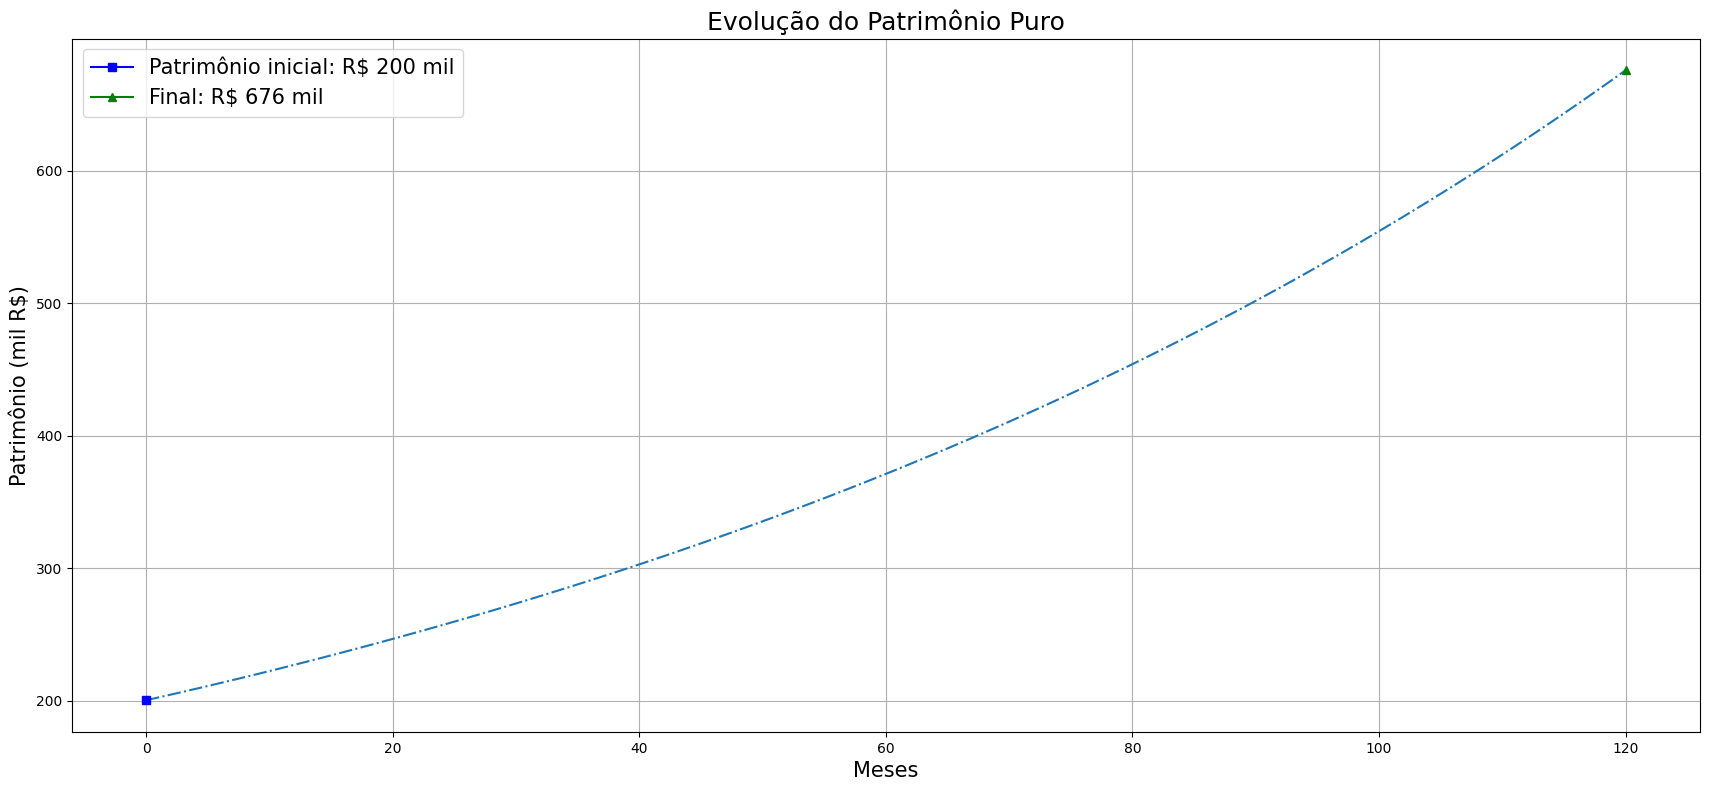

In [15]:
vis.plot_puro(P0_1, Am_1, rm_1, mm_1, Th_1)

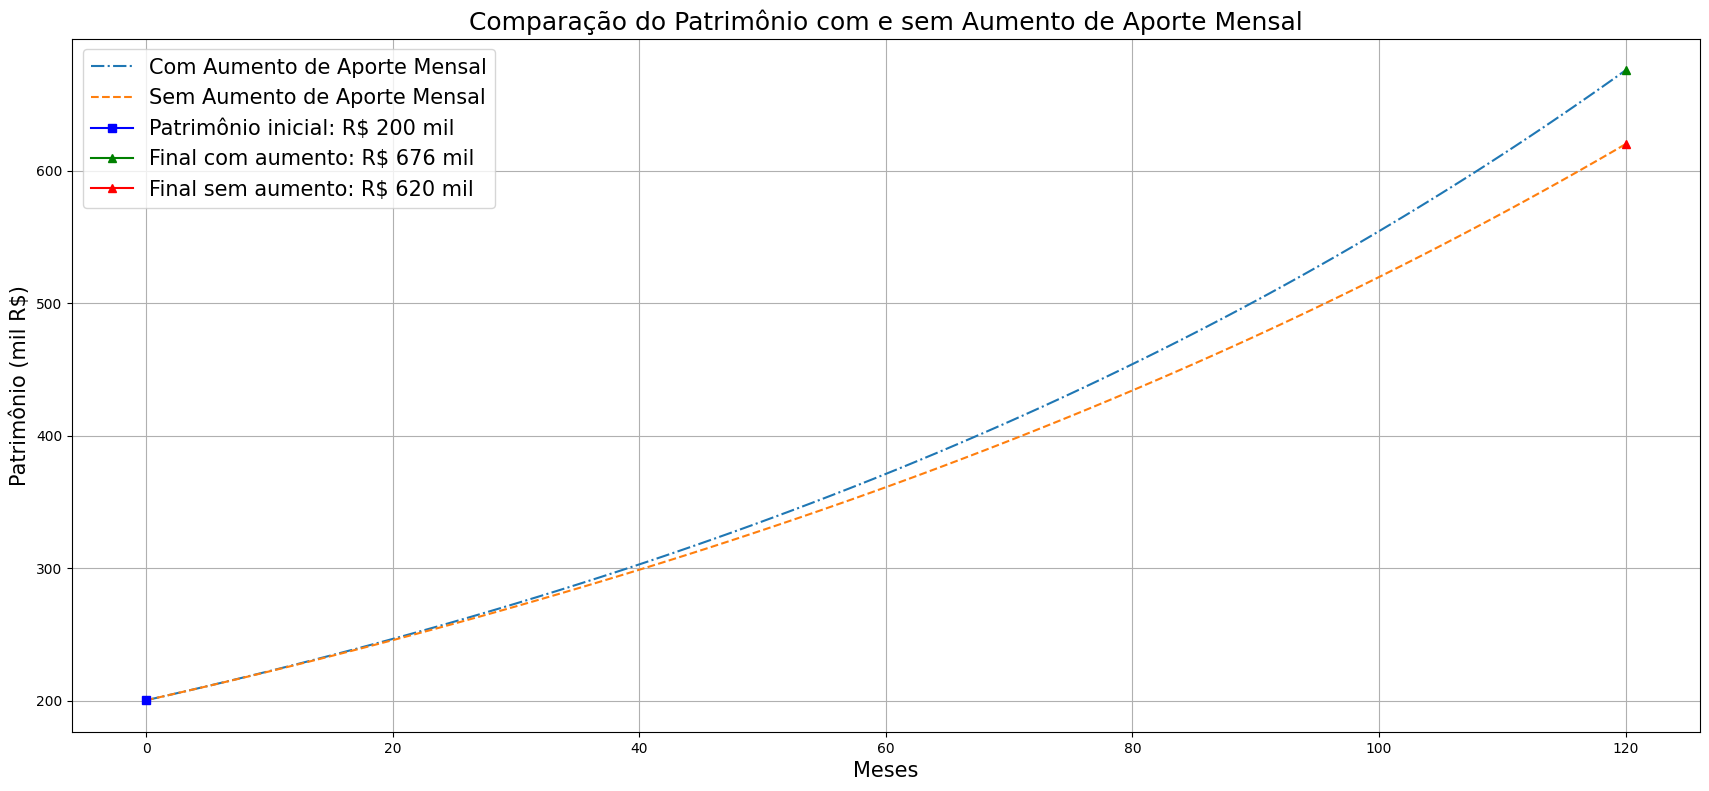

In [16]:
vis.plot_vantagem_aumento(P0_1, Am_1, rm_1, mm_1, Th_1)

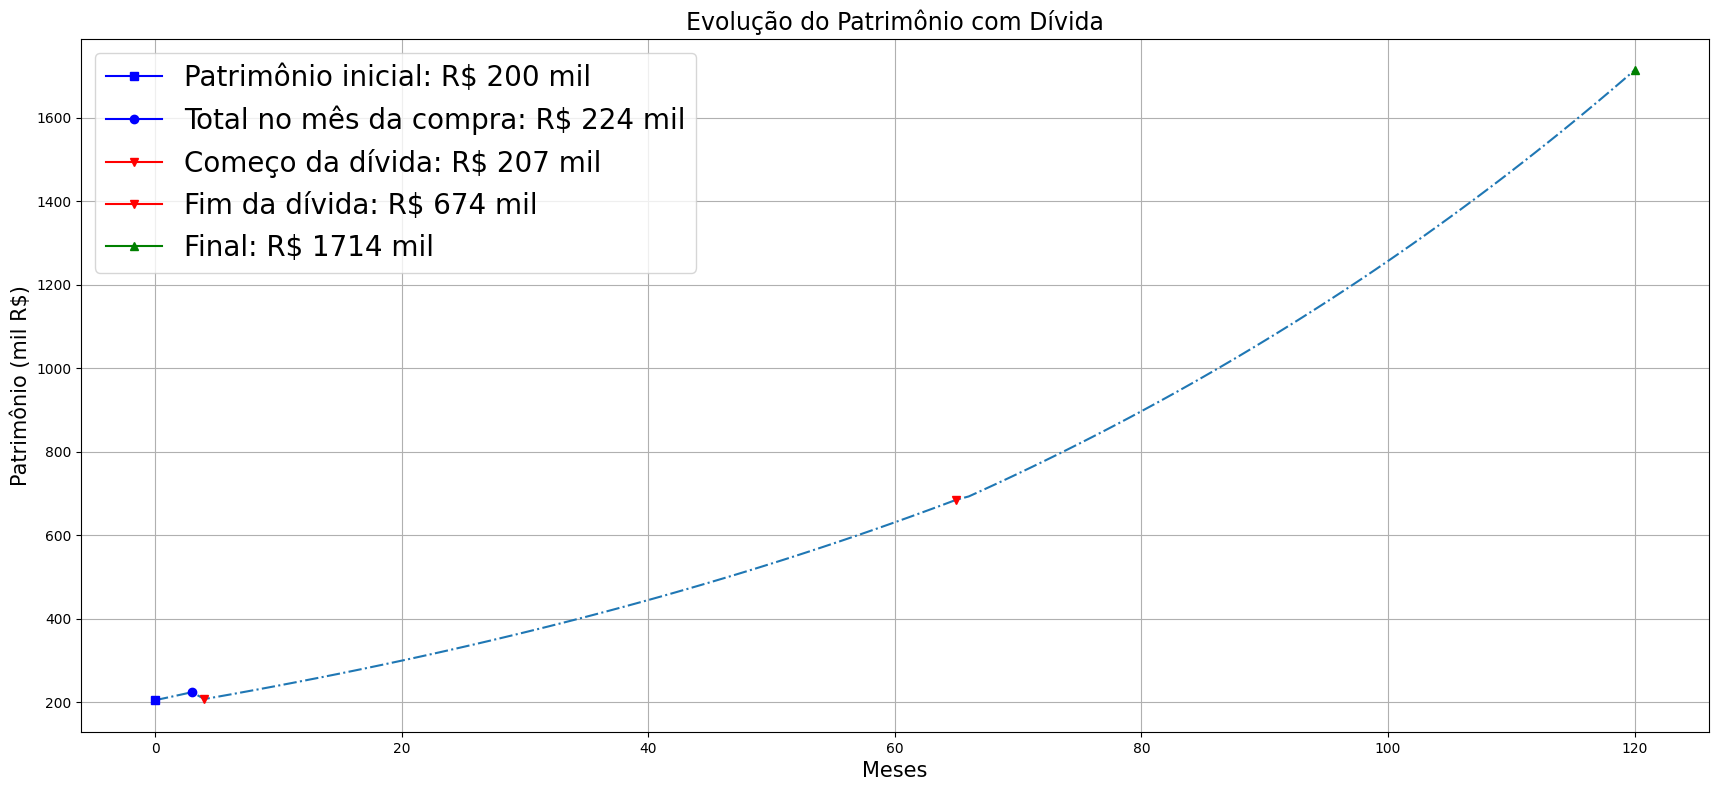

In [17]:
vis.plot_in_debt_buy(P0_1, 
                  Am_1, 
                    rm_1,
                    mm_1,
                    Th_1,
                    Vv_1,
                    Vv_1*0.1,
                    Vp_1*2,
                    Vm_1,
                    Gr_1,
                    Tc_1,
                    Jm_1)

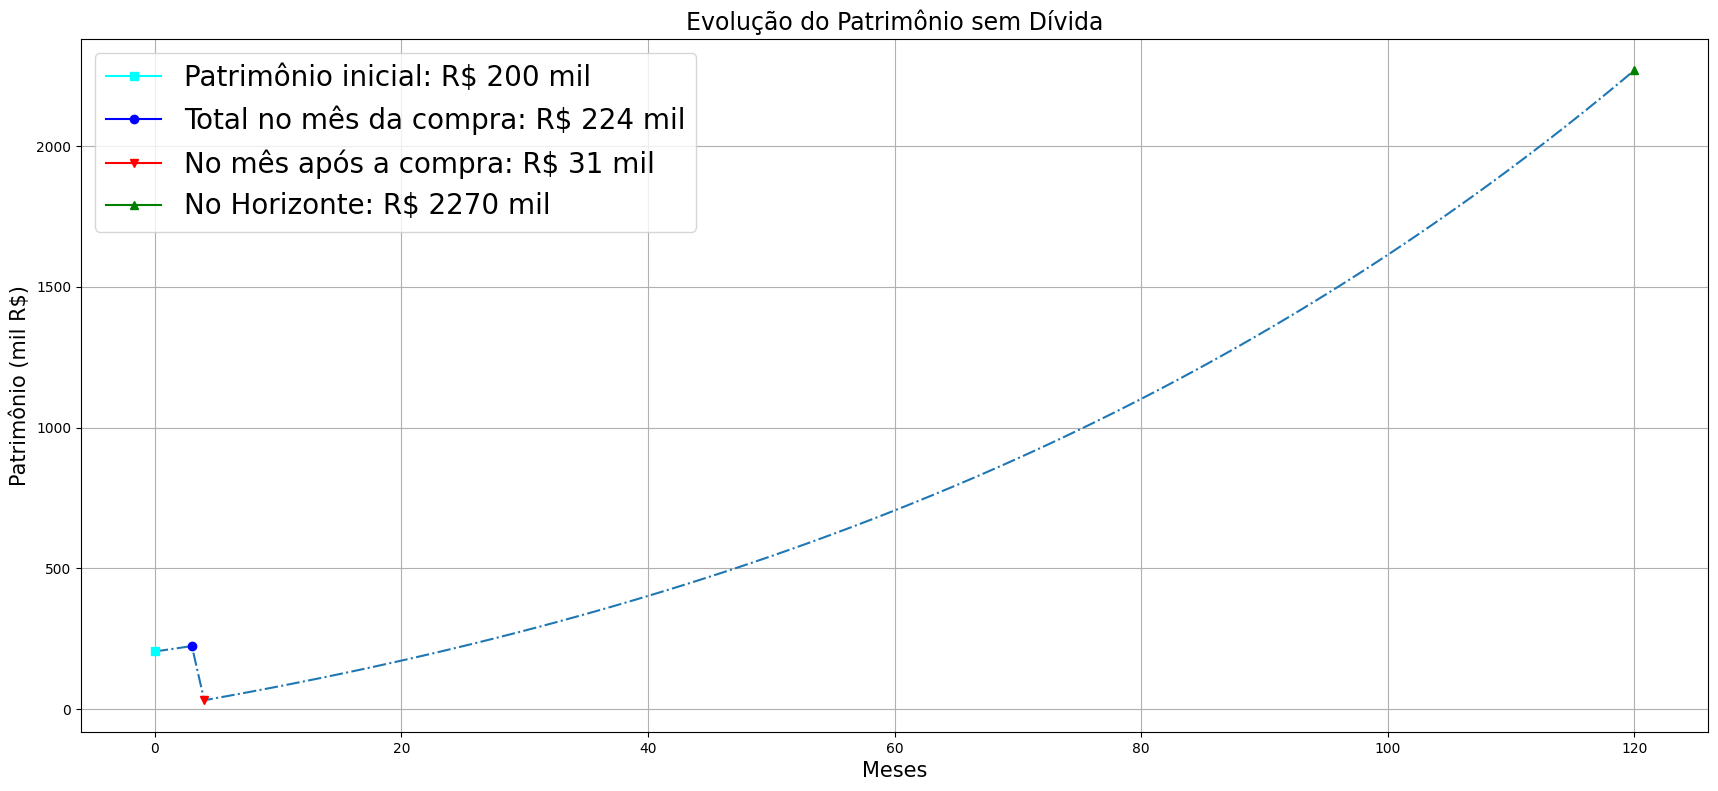

In [18]:
vis.plot_in_full_buy(P0_1,
                    Am_1,
                    rm_1,
                    mm_1,
                    Th_1,
                    Vv_1,
                    Vm_1,
                    Gr_1,
                    Tc_1,
                    Vp_1*2)

In [19]:
def plot_in_full_versus_in_debt(
    patrimonio_inicial,
    aporte_mensal_fixo,
    rendimento_mensal,
    aumento_aporte_mensal,
    tempo_horizonte,
    valor_vista,
    valor_entrada,
    valor_parcela,
    valor_manutencao,
    ganho_problema,
    mes_compra,
    juros_mensais
):
    """
    Compare the evolution of net worth over time for two purchase strategies:
    financing ("in debt") versus paying in full ("in full").

    This function simulates and plots the user's patrimony trajectory under
    two scenarios:

    1. Financing the purchase through installments and interest payments.
    2. Paying the full purchase price upfront and continuing investments afterward.

    The resulting curves are displayed together for direct comparison.

    Parameters
    ----------
    patrimonio_inicial : float
        Initial patrimony or invested capital before the purchase.

    aporte_mensal_fixo : float
        Initial fixed monthly contribution added to the investments.

    rendimento_mensal : float
        Monthly investment return rate.

    aumento_aporte_mensal : float
        Monthly multiplicative growth factor for contributions.

    tempo_horizonte : int
        Total simulation time horizon in months.

    valor_vista : float
        Total purchase price if paid in full upfront.

    valor_entrada : float
        Down payment used in the financing scenario.

    valor_parcela : float
        Monthly installment payment in the financing scenario.

    valor_manutencao : float
        Monthly maintenance or ownership cost associated with the asset.

    ganho_problema : float
        Additional monthly financial gain or savings generated after purchase.

    mes_compra : int
        Month in which the purchase occurs.

    juros_mensais : float
        Monthly financing interest rate.

    Returns
    -------
    None
        Displays a matplotlib figure comparing patrimony trajectories for
        both purchase methods.

    Notes
    -----
    The function internally divides patrimony values by 1000 before plotting,
    so the graph is displayed in units of thousand reais (R$ mil).

    The financing simulation is divided into three stages:

    - Before the purchase
    - During the financing period
    - After the debt is fully paid

    Important milestones are highlighted in the plot, including:

    - Initial patrimony
    - Patrimony at purchase month
    - Beginning of debt
    - End of debt
    - Final patrimony at the investment horizon
    """
    
    ###
    # in debt simulation:
    ###
    
    num_parcelas = loan.encontrar_numero_parcelas(
        loan.tabela_comparativa(valor_vista, valor_entrada, juros_mensais),
        valor_parcela
    )

    meses_apos = tempo_horizonte - mes_compra - num_parcelas

    serie_antes = eq.patrimonio_antes_por_tempo(
        patrimonio_inicial, 
        aporte_mensal_fixo, 
        rendimento_mensal, 
        aumento_aporte_mensal, 
        mes_compra,
        valor_parcela,
        valor_manutencao
    )

    serie_durante = eq.patrimonio_durante_por_tempo(
        patrimonio_inicial, 
        aporte_mensal_fixo, 
        rendimento_mensal, 
        aumento_aporte_mensal, 
        mes_compra,
        valor_vista, 
        valor_entrada, 
        valor_parcela, 
        juros_mensais, 
        valor_manutencao, 
        ganho_problema
    )

    serie_apos = eq.patrimonio_apos_por_tempo(
        patrimonio_inicial, 
        aporte_mensal_fixo, 
        rendimento_mensal, 
        aumento_aporte_mensal, 
        meses_apos,
        valor_vista, 
        valor_entrada, 
        valor_parcela, 
        valor_manutencao, 
        ganho_problema, 
        mes_compra, 
        juros_mensais
    )

    patrimonio_por_tempo_debt = (
        serie_antes +
        serie_durante[:] +
        serie_apos[:]
    )
    
    mes_fim_divida = mes_compra + num_parcelas +1
    mes_final = len(patrimonio_por_tempo_debt) - 1

    if mes_fim_divida > tempo_horizonte:
        mes_fim_divida = tempo_horizonte    

    if mes_final > tempo_horizonte:
        mes_final = tempo_horizonte

    for i in range(len(patrimonio_por_tempo_debt)):
        patrimonio_por_tempo_debt[i] = patrimonio_por_tempo_debt[i] / 1000

    ###
    # in full simulation:
    ###

    patrimonio_por_tempo_full = []

    #append do patrimônio por tempo antes da dívida:
    patrimonio_por_tempo_full.extend(eq.patrimonio_antes_por_tempo(patrimonio_inicial, 
                                                           aporte_mensal_fixo, 
                                                           rendimento_mensal, 
                                                           aumento_aporte_mensal, 
                                                           mes_compra,
                                                           valor_parcela,
                                                           valor_manutencao))

    patrimonio_apos_compra = patrimonio_por_tempo_full[mes_compra-1] - valor_vista
    
    # aporte mensal resultante após a compra:
    aporte_mensal_apos = aporte_mensal_fixo * (aumento_aporte_mensal ** mes_compra) + ganho_problema + valor_parcela

    # tempo desde a compra até o horizonte:
    meses_apos_compra = tempo_horizonte -  mes_compra

    #append do patrimônio por tempo após a dívida:
    patrimonio_por_tempo_full.extend(eq.patrimonio_puro_por_tempo(patrimonio_apos_compra,
                                                           aporte_mensal_apos,
                                                           rendimento_mensal,
                                                           aumento_aporte_mensal,
                                                           meses_apos_compra))
    
    for i in range(len(patrimonio_por_tempo_full)):
        patrimonio_por_tempo_full[i] = patrimonio_por_tempo_full[i] / 1000

    ###
    # plot in debt:
    ###

    plt.figure(figsize=(21,9))
    plt.plot(patrimonio_por_tempo_debt[0:tempo_horizonte+1], '-.')
    
    ###
    # plot in full:
    ###
    plt.plot(patrimonio_por_tempo_full, '--')

    ###
    #info:
    ###
    
    # inicial
    plt.plot(0,
                patrimonio_por_tempo_debt[0],
                marker='s',
                color='brown',
                label=f'Patrimônio inicial: R$ {patrimonio_inicial*1e-3:.0f} mil')

    # compra
    plt.plot(mes_compra-1,
                patrimonio_por_tempo_debt[mes_compra-1],
                marker='s',
                color='brown',
                label=f'Total no mês da compra: R$ {patrimonio_por_tempo_debt[mes_compra-1]:.0f} mil')
    
    # começo da dívida
    plt.plot(mes_compra,
                patrimonio_por_tempo_debt[mes_compra],
                marker='v',
                color='darkblue',
                label=f'No começo da dívida: R$ {patrimonio_por_tempo_debt[mes_compra]:.0f} mil')
    
    plt.plot(mes_compra,
             patrimonio_por_tempo_full[mes_compra],
             marker='v', 
             color = 'darkorange', 
             label=f'No mês após a compra à vista: R$ {patrimonio_por_tempo_full[mes_compra]:.0f} mil')
    
    # fim da dívida
    plt.plot(mes_fim_divida-1,
                patrimonio_por_tempo_debt[mes_fim_divida-1],
                marker='^',
                color='darkblue',
                label=f'No fim da dívida: R$ {patrimonio_por_tempo_debt[mes_fim_divida-1]:.0f} mil')
    
    plt.plot(tempo_horizonte,
             patrimonio_por_tempo_full[tempo_horizonte],
             marker='o',
             color = 'darkorange', 
             label=f'No Horizonte (à vista): R$ {patrimonio_por_tempo_full[tempo_horizonte]:.0f} mil')
    
    # final
    plt.plot(mes_final,
                patrimonio_por_tempo_debt[mes_final],
                marker='o',
                color='darkblue',
                label=f'No Horizonte (dívida): R$ {patrimonio_por_tempo_debt[mes_final]:.0f} mil')
    
    for i in range(len(patrimonio_por_tempo_full)):
        patrimonio_por_tempo_full[i] = patrimonio_por_tempo_full[i] / 1000

    
    # layout
    plt.title('Comparação de Métodos de Compra',fontsize=17)
    plt.xlabel('Meses',fontsize=15)
    plt.ylabel('Patrimônio (mil R$)',fontsize=15)
    plt.ticklabel_format(style='plain', axis='y')
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

    return None

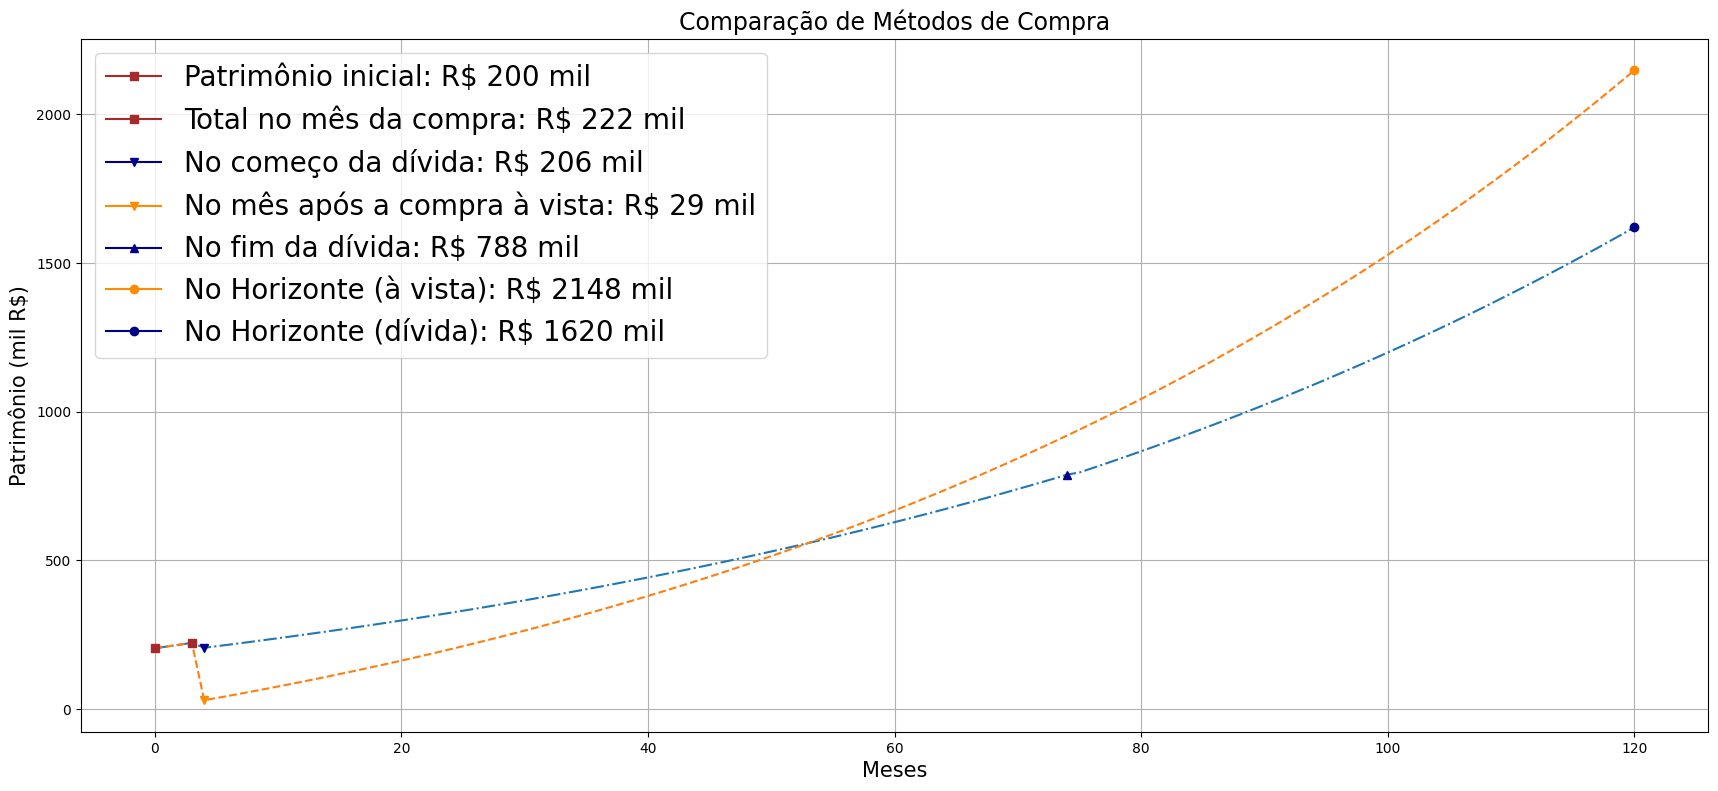

In [20]:
plot_in_full_versus_in_debt(P0_1, 
                  Am_1, 
                    rm_1,
                    mm_1,
                    Th_1,
                    Vv_1,
                    Vv_1*0.1,
                    Vp_1*1.8,
                    Vm_1,
                    Gr_1,
                    Tc_1,
                    Jm_1)